Code for calculating the barotropic and overturning streamfunctions for both ANHA4 and ANHA12. This assumes that for the barotropic streamfunction, you start from the north and work your way down

In [8]:
import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset

import datetime
import cftime
import time

import gsw

In [96]:
def barotropic_sf(ds, ds_mask, model, hgr = 0, zgr = 0):

    if model == 'ANHA4':
        v_t = ds['vomecrty'][0,:,:,:]
        v_z = ds['e3v'][0, :, :,:]
        v_x = ds_mask['e1v'][0, :,:]
    else:
        v_t = ds['vomecrty'][0,:,:,:].rename({'depthv':'z'})
        v_z = zgr['e3v'][0, :, :,:]
        v_x = hgr['e1v'][0, :,:]
        
    btsf = np.cumsum(np.sum(v_t * v_z, axis = 0) * v_x, axis = 1)

    return btsf

def barotropic_plotter(ds, ds_mask, btsf, inds, model):
    sf = np.where(ds_mask['vmask'][0,0,inds[0]:inds[1],inds[2]:inds[3]], btsf[inds[0]:inds[1],inds[2]:inds[3]] / 1e6, np.nan)
    m = np.nanmax(np.abs([np.nanmin(sf), np.nanmax(sf)]))
    plt.contourf(sf, np.arange(-80, 80, 10), cmap = 'coolwarm')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.colorbar()

    if model == 'ANHA4':
        plt.title('ANHA4 Barotropic Streamfunction (5/25/2018)')
        plt.yticks(np.arange(25,200, 25), np.trunc(ds.nav_lat.values[275:450, 150][::25] * 100) / 100)
        plt.xticks(np.arange(25,225, 45), np.trunc(ds.nav_lon.values[250, 175:375][::45] * 100) / 100)
    else:
        plt.title('ANHA12 Barotropic Streamfunction (5/25/2018)')
        plt.yticks([100, 200, 300, 400, 500, 600], np.trunc(ds.nav_lat.values[750:1350, 450][::100] * 100) / 100)
        plt.xticks([100, 200, 300, 400, 500, 600], np.trunc(ds.nav_lon.values[750, 450:1000][::100] * 100) / 100)

    plt.show()

In [97]:
def overturning_sf(ds, ds_mask, model, hgr = 0, zgr = 0):
    if model == 'ANHA4':
        v_t = ds['vomecrty'][0,:,:,:]
        v_z = ds['e3v'][0, :, :,:]
        v_x = ds_mask['e1v'][0, :,:]
    else:
        v_t = ds['vomecrty'][0,:,:,:].rename({'depthv':'z'})
        v_z = zgr['e3v'][0, :, :,:]
        v_x = hgr['e1v'][0, :,:]
    temp = np.sum(v_t * v_z * v_x, axis = 2)
    temp = np.where(temp != 0, temp, np.nan)
    mosf = np.cumsum(temp, axis = 0)

    return mosf
    
def overturning_plotter(ds, mosf, inds, model):
    
    if model == 'ANHA4':
        plt.contourf(ds['y'][inds[0]:inds[1]], ds['depth'][:].values, mosf[:,inds[0]:inds[1]] / 1e6, np.arange(-24, 24, 4), cmap = 'coolwarm')
        plt.title('ANHA4 Overturning SPG (Sv) 5/25/2018')
        plt.xticks(np.arange(inds[0], inds[1], 25)[1:], np.trunc(ds.nav_lat.values[inds[0]:inds[1], 250][::25][1:] * 100) / 100)
    
    else:
        plt.contourf(ds['y'][inds[0]:inds[1]], ds['depthv'][:].values, mosf[:,inds[0]:inds[1]] / 1e6, np.arange(-24, 24, 4),cmap = 'coolwarm')
        plt.title('ANHA12 Overturning SPG (Sv) 5/25/2018')
        plt.xticks(np.arange(inds[0], inds[1], 75)[1:], np.trunc(ds.nav_lat.values[inds[0]:inds[1], 800][::75][1:] * 100) / 100)

    plt.gca().invert_yaxis()
    plt.colorbar()
    plt.ylabel('Depth (meters)')
    plt.xlabel('Latitude')
    plt.show()
    

In [98]:
v = xr.open_dataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridV.nc").rename({'depthv': 'depth'})
mask = xr.open_dataset('/mnt/storage4/grace/grace/data/model_masks/ANHA4_mesh_mask.nc')

v12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2018m05d25_gridV.nc", chunks={'y':800, 'x':544, 'depthv':25})
mask12 = xr.open_mfdataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mask.nc')
hgr = xr.open_mfdataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mesh_hgr.nc')
zgr = xr.open_mfdataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mesh_zgr.nc', chunks={'y':800, 'x':544, 'z':25})

In [99]:
mosf4 = overturning_sf(v, mask, 'ANHA4', hgr = 0, zgr = 0)

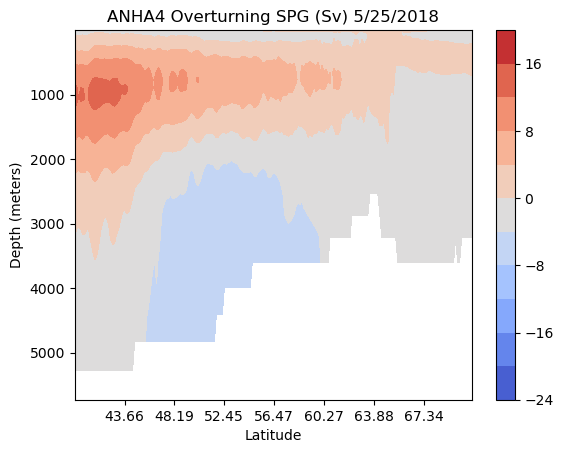

In [101]:
overturning_plotter(v, mosf4, [250,450], 'ANHA4')

In [102]:
mosf12 = overturning_sf(v12, mask12, 'ANHA12', hgr = hgr, zgr = zgr)

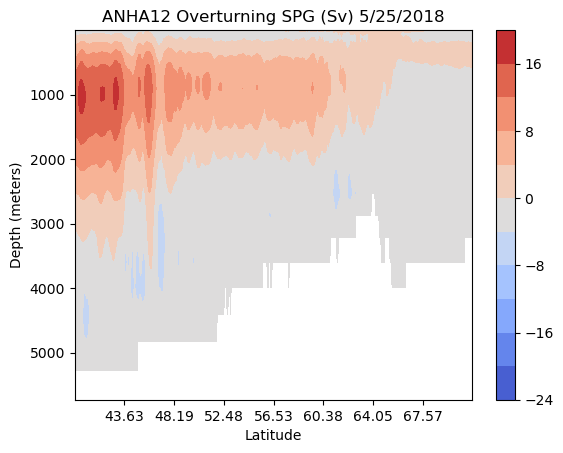

In [103]:
overturning_plotter(v12, mosf12, [750,1350], 'ANHA12')

In [104]:
bt4 = barotropic_sf(v, mask, 'ANHA4')

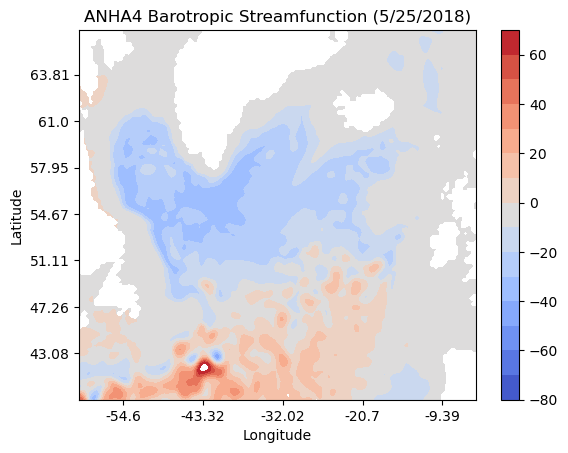

In [105]:
barotropic_plotter(v, mask, bt4, [250,450,150,375], 'ANHA4')

In [106]:
bt12 = barotropic_sf(v12, mask12, model = 'ANHA12', hgr = hgr, zgr = zgr)

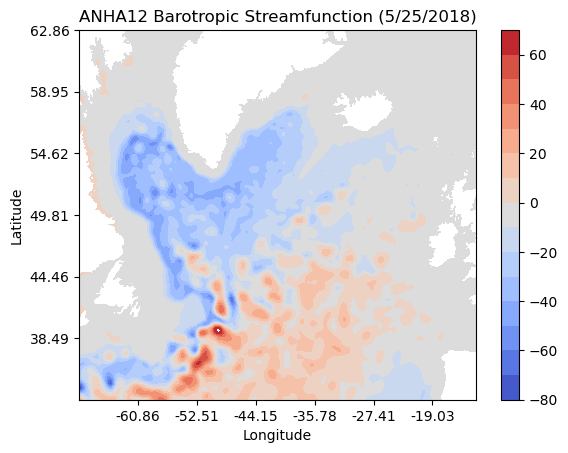

In [107]:
barotropic_plotter(v12, mask12, bt12, [750,1350,450,1125], 'ANHA12')